In [1]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Problema de classificação desbalançeada

In [2]:
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


Feature Engineering

In [3]:
import numpy as np

df["Amount_log"] = np.log1p(df["Amount"])

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

Logistic Regression

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.66      0.73       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



Accuracy pode ser alta mesmo sem detectar fraudes.

Por isso usamos:
  - Recall (mais importante)
  - Precision
  - F1-score

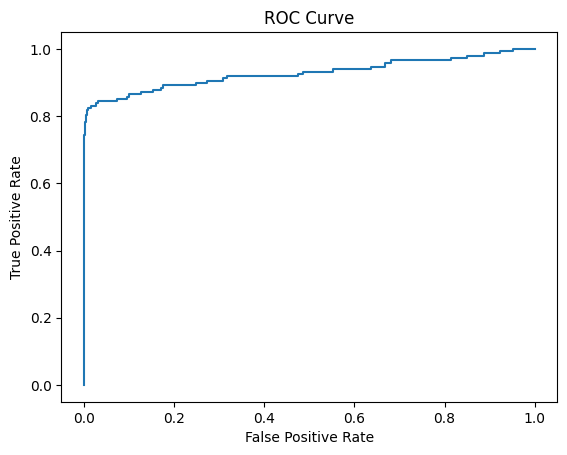

AUC: 0.9272042339543365


In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

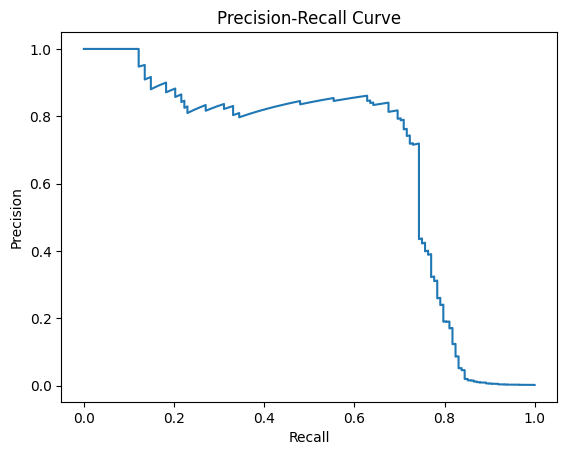

In [10]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

Balanceamento de Dados

In [11]:
# Undersampling
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [12]:
# Oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_res, y_res = smote.fit_resample(X, y)

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [14]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [15]:
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.71      0.75       148

    accuracy                           1.00     85443
   macro avg       0.89      0.85      0.87     85443
weighted avg       1.00      1.00      1.00     85443



Modelo Avançado - XGBoost

XGBoost é um dos algoritmos mais usados em competições e mercado.

Ele é mais poderoso que Random Forest para muitos problemas.

In [16]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Divisão dos dados (caso ainda não tenha feito)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 2. Criando o modelo XGBoost melhor configurado
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=10,
    eval_metric="logloss",
    random_state=42
)

# 3. Treinamento
xgb.fit(X_train, y_train)

# 4. Previsões
y_pred = xgb.predict(X_test)

# 5. Avaliação do modelo
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

Acurácia: 0.9995084442259752

Matriz de Confusão:
 [[56852    12]
 [   16    82]]

Relatório de Classificação:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [17]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb, X, y, cv=5, scoring='accuracy')

print("Acurácia média (cross-validation):", scores.mean())

Acurácia média (cross-validation): 0.9991292372769711


Importância das variáveis

Ajuda a entender quais variáveis influenciam mais o modelo.

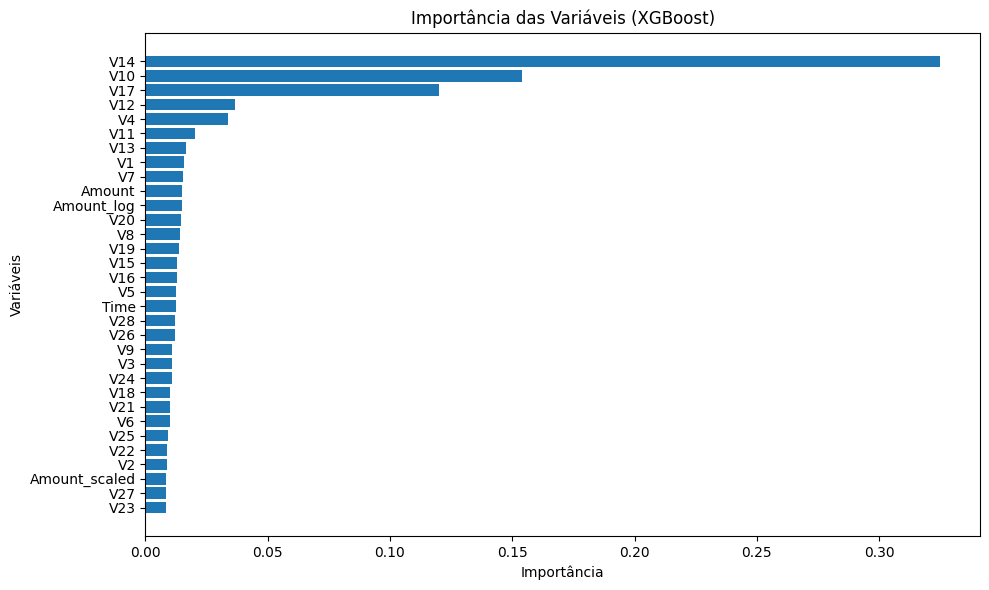

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Importâncias do modelo
importancias = xgb.feature_importances_

# Criando um DataFrame para organizar melhor
feat_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importancias
})

# Ordenando do mais importante para o menos importante
feat_importance = feat_importance.sort_values(by='importance', ascending=True)

# Plot mais legível (horizontal)
plt.figure(figsize=(10, 6))
plt.barh(feat_importance['feature'], feat_importance['importance'])

plt.title("Importância das Variáveis (XGBoost)")
plt.xlabel("Importância")
plt.ylabel("Variáveis")

plt.tight_layout()
plt.show()

Ajuste de hiperparâmetros

Testamos várias combinações para melhorar o modelo.

In [19]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    verbosity=0
)

param_dist = {
    "max_depth": [3, 5],
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

cv = StratifiedKFold(
    n_splits=2,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("Melhores parâmetros:", random_search.best_params_)
print("Melhor recall:", random_search.best_score_)

Fitting 2 folds for each of 8 candidates, totalling 16 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Melhores parâmetros: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Melhor recall: 0.7639593908629442


Explicabilidade (SHAP)

SHAP mostra como cada variável influencia a decisão do modelo.

Importância Global das Variáveis


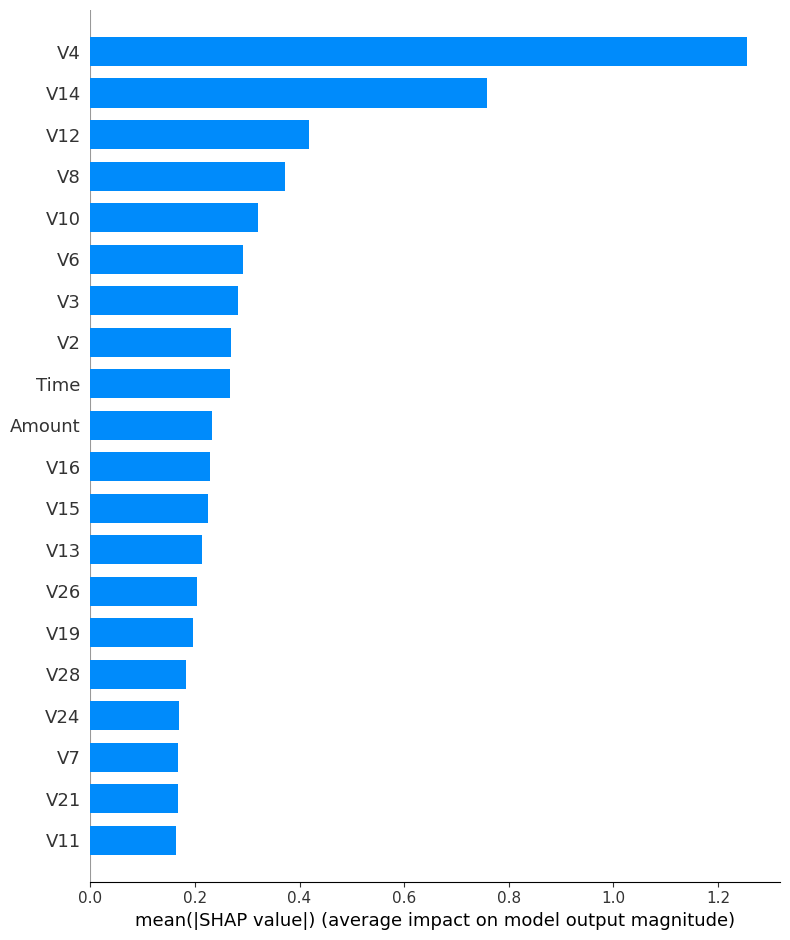

Impacto das Variáveis nas Previsões


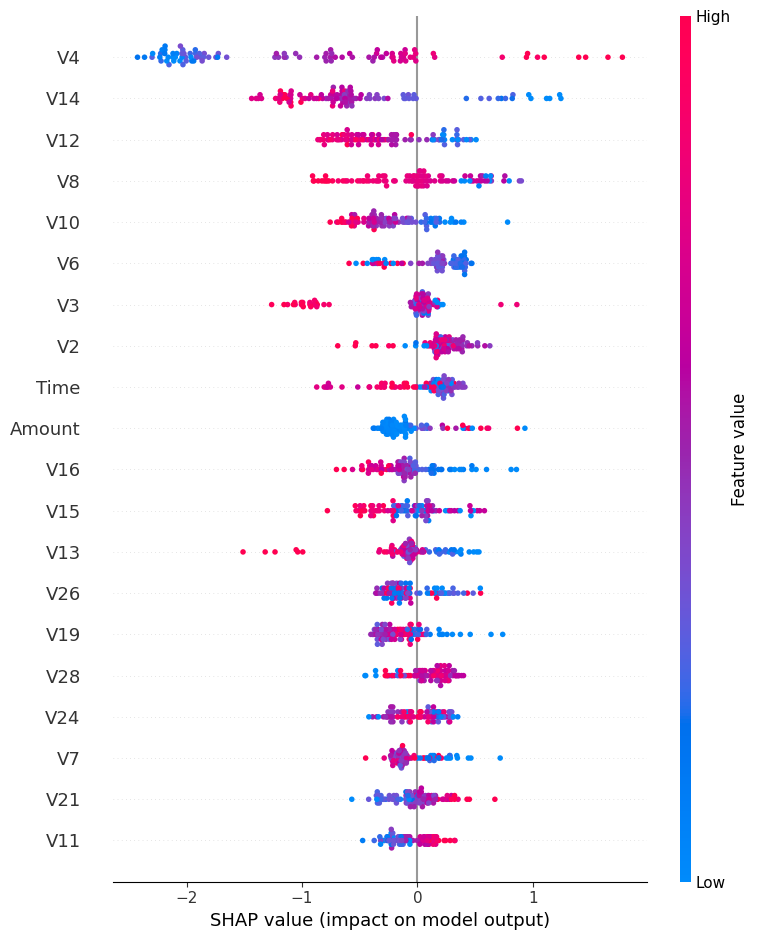

In [21]:
import shap
import matplotlib.pyplot as plt

# Utiliza apenas uma amostra para acelerar o processamento
X_sample = X_test.sample(
    n=min(100, len(X_test)),
    random_state=42
)

# Explainer específico para árvores (mais rápido para XGBoost)
explainer = shap.TreeExplainer(best_model)

# Calcula os valores SHAP
shap_values = explainer.shap_values(X_sample)

# 1. Importância global das variáveis
print("Importância Global das Variáveis")

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

# 2. Impacto das variáveis nas previsões
print("Impacto das Variáveis nas Previsões")

shap.summary_plot(
    shap_values,
    X_sample
)

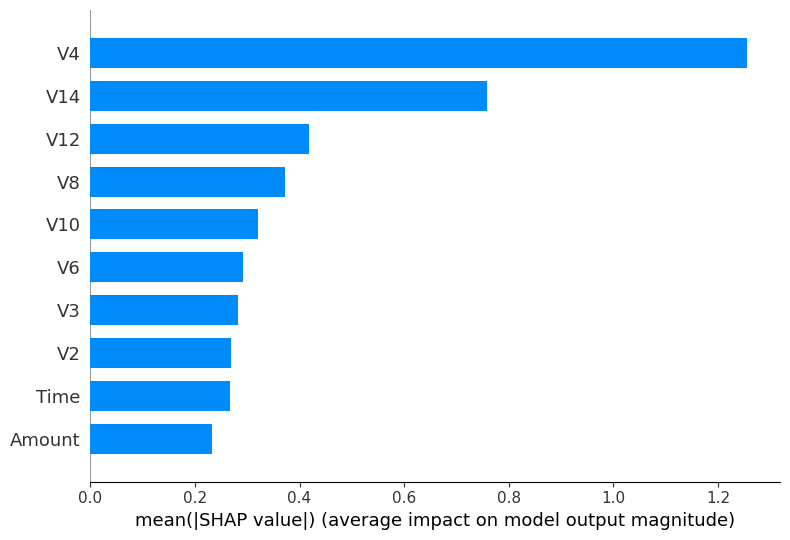

In [22]:
# Top 10 variáveis mais importantes

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    max_display=10
)